In [1]:
import time
import os
import re

import porespy as ps
import numpy as np
import scipy as sc
import xarray as xr
from pypardiso import spsolve
from scipy.sparse import csr_matrix

os.chdir("..")
%run .\pyflowsolver\volumeManager.py
%run .\pyflowsolver\sparseArray.py
%run .\pyflowsolver\fastLaplacian.py
%run .\pyflowsolver\darcySolver.py
os.chdir("notebooks")

In [2]:
folder = r"D:\Geoslicer\benthimer_eval\numerical_compare\netcdf\\"
files = ["solved\BIN_Bentheimer000.nc", "solved_openfoam\Bentheimer_DRP_000_OpenFOAM.nc"]

In [7]:
openfoam_dataset = xr.open_dataset(f"{folder}\{files[1]}")
pyflowsolver_dataset = xr.open_dataset(f"{folder}\{files[0]}")
print(f"OPF: {openfoam_dataset.keys()}\n\nPFS:{pyflowsolver_dataset.keys()}")

OPF: KeysView(<xarray.Dataset> Size: 125MB
Dimensions:     (z_float: 250, y_float: 250, x_float: 250, z_porosity: 250,
                 y_porosity: 250, x_porosity: 250)
Coordinates:
  * z_float     (z_float) float64 2kB 0.0 1.0 2.0 3.0 ... 247.0 248.0 249.0
  * y_float     (y_float) float64 2kB 0.0 1.0 2.0 3.0 ... 247.0 248.0 249.0
  * x_float     (x_float) float64 2kB 0.0 1.0 2.0 3.0 ... 247.0 248.0 249.0
  * z_porosity  (z_porosity) float64 2kB 0.0 1.0 2.0 3.0 ... 247.0 248.0 249.0
  * y_porosity  (y_porosity) float64 2kB 0.0 1.0 2.0 3.0 ... 247.0 248.0 249.0
  * x_porosity  (x_porosity) float64 2kB 0.0 1.0 2.0 3.0 ... 247.0 248.0 249.0
Data variables:
    float       (z_float, y_float, x_float) float32 62MB ...
    porosity    (z_porosity, y_porosity, x_porosity) float32 62MB ...
Attributes:
    geoslicer_version:  2.4.119)

PFS:KeysView(<xarray.Dataset> Size: 125MB
Dimensions:   (x: 250, y: 250, z: 250)
Coordinates:
  * x         (x) int32 1kB 0 1 2 3 4 5 6 7 ... 242 243 244 245 2

In [34]:
pfs_speed = np.swapaxes(pyflowsolver_dataset["speed"].values, 0, 2)
pfs_pressure = np.swapaxes(pyflowsolver_dataset["pressure"].values, 0, 2)
opf_speed = openfoam_dataset["float"].values
opf_pressure = openfoam_dataset["porosity"].values

In [35]:
print(opf_pressure[-1,:,:].sum(), opf_pressure[0,:,:].sum(), opf_speed[-1,:,:].sum(), opf_speed[0,:,:].sum())

0.0030370376 14.73991 167.19418 158.01454


In [36]:
print(pfs_pressure[-1,:,:].sum(), pfs_pressure[0,:,:].sum(), pfs_speed[-1,:,:].sum(), pfs_speed[0,:,:].sum())

44.647484 48024.367 10947.362 10950.336


In [40]:
print(np.nan_to_num((pfs_speed / opf_speed)).min())
print(np.nan_to_num((pfs_speed / opf_speed)).max())

-3.4028235e+38
3.4028235e+38


In [44]:
print(opf_pressure.max(), pfs_pressure.max())
print(opf_pressure.min(), pfs_pressure.min())

0.0010108629 1.000014
-4.9519233e-05 -2.1367898e-06


In [45]:
opf_pressure_norm = opf_pressure/opf_pressure.max()
opf_speed_norm = opf_speed/opf_pressure.max()

In [46]:
pfs_pressure-opf_pressure_norm

array([[[ 9.96430337e-01,  9.96423542e-01,  9.96413112e-01, ...,
          9.99922216e-01,  9.99920428e-01,  9.99919534e-01],
        [ 9.96426105e-01,  9.96418178e-01,  9.96405840e-01, ...,
          9.99923289e-01,  9.99921620e-01,  9.99920726e-01],
        [ 9.96414900e-01,  9.96406972e-01,  9.96391952e-01, ...,
          9.99925494e-01,  9.99923944e-01,  9.99923110e-01],
        ...,
        [-9.89097953e-01, -9.89105463e-01, -9.89119709e-01, ...,
          9.99941051e-01,  9.99941289e-01,  9.99941468e-01],
        [-9.89093721e-01, -9.89102602e-01, -9.89116967e-01, ...,
          9.99941170e-01,  9.99941409e-01,  9.99941528e-01],
        [-9.89086330e-01, -9.89100635e-01, -9.89117444e-01, ...,
          9.99941170e-01,  9.99941468e-01,  9.99941587e-01]],

       [[ 9.89301264e-01,  9.89278197e-01,  9.89244163e-01, ...,
          9.99757171e-01,  9.99751627e-01,  9.99748826e-01],
        [ 9.89291430e-01,  9.89262223e-01,  9.89221096e-01, ...,
          9.99760628e-01,  9.99755263e

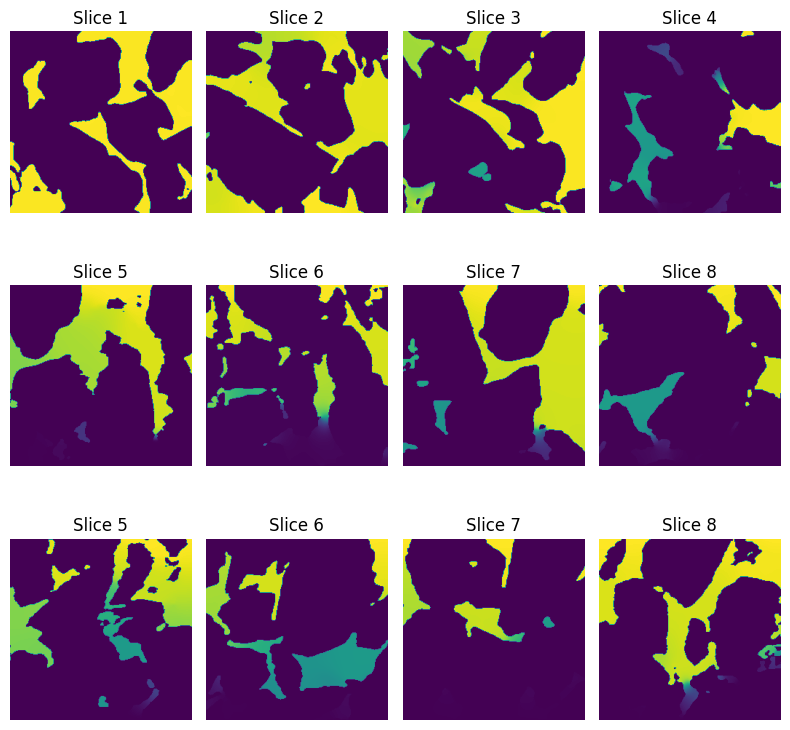

In [51]:
import matplotlib.pyplot as plt

num_slices = 4
step = opf_pressure_norm.shape[2] // num_slices
fig, axs = plt.subplots(3, num_slices, figsize=(8, 8))

for i in range(num_slices):
    slice_2d = opf_pressure_norm[i*step, :, :]
    axs[0,i].imshow(slice_2d, cmap='viridis', origin='upper')
    axs[0,i].set_title(f'Slice {i + 1}')
    axs[0,i].axis('off')  # Turn off axis for better visualization

    slice_2d = opf_pressure_norm[:, i*step, :]
    axs[1,i].imshow(slice_2d, cmap='viridis', origin='upper')
    axs[1,i].set_title(f'Slice {i + 1 + 4}')
    axs[1,i].axis('off')  # Turn off axis for better visualization

    slice_2d = opf_pressure_norm[:, :, i*step]
    axs[2,i].imshow(slice_2d, cmap='viridis', origin='upper')
    axs[2,i].set_title(f'Slice {i + 1 + 4}')
    axs[2,i].axis('off')  # Turn off axis for better visualization

plt.tight_layout()
plt.show()

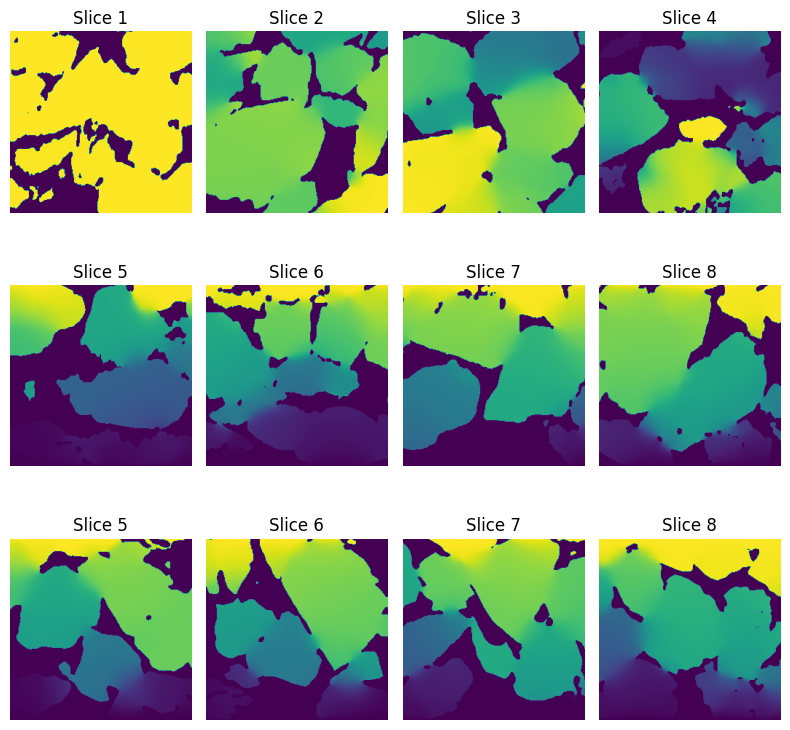

In [52]:
import matplotlib.pyplot as plt

num_slices = 4
step = pfs_pressure.shape[2] // num_slices
fig, axs = plt.subplots(3, num_slices, figsize=(8, 8))

for i in range(num_slices):
    slice_2d = pfs_pressure[i*step, :, :]
    axs[0,i].imshow(slice_2d, cmap='viridis', origin='upper')
    axs[0,i].set_title(f'Slice {i + 1}')
    axs[0,i].axis('off')  # Turn off axis for better visualization

    slice_2d = pfs_pressure[:, i*step, :]
    axs[1,i].imshow(slice_2d, cmap='viridis', origin='upper')
    axs[1,i].set_title(f'Slice {i + 1 + 4}')
    axs[1,i].axis('off')  # Turn off axis for better visualization

    slice_2d = pfs_pressure[:, :, i*step]
    axs[2,i].imshow(slice_2d, cmap='viridis', origin='upper')
    axs[2,i].set_title(f'Slice {i + 1 + 4}')
    axs[2,i].axis('off')  # Turn off axis for better visualization

plt.tight_layout()
plt.show()